# EMMA Tutorial

This notebook restores the real missing rows/columns already present in the selected Hi-C window.

- fixed region: `chr2`, `mat[12500:15000, 12500:15000]`
- no artificial missing region
- 500 window region
- missing mask detected from the matrix itself
- `recompute_pseudo_emd=True` for higher-quality pseudo-mask training
- stronger context initialization
- overlapping inference patches
- conservative MAE replacement and mild post-processing

Runtime note: EMMA uses CPU for Stage 0/1 context initialization and EMD decomposition. GPU usage starts at Stage 2, when the Masked IMF AutoEncoder begins training.


In [1]:
import sys
import subprocess

print("[Python version]", sys.version)

if sys.version_info < (3, 9):
    raise RuntimeError(
        "emma-3dgenome >=0.2.0 requires Python >=3.9. "
        "Please switch to the Jupyter kernel: Python (chromnet)."
    )

print("[Verify pip package]")
subprocess.run([sys.executable, "-m", "pip", "show", "emma-3dgenome"], check=False)

try:
    import emma_3dgenome
except ImportError as exc:
    raise RuntimeError(
        "emma-3dgenome is not installed in this kernel. "
        "Install it with: python -m pip install -U emma-3dgenome"
    ) from exc

def version_tuple(v):
    parts = []
    for part in str(v).split("."):
        digits = "".join(ch for ch in part if ch.isdigit())
        if digits:
            parts.append(int(digits))
    return tuple(parts + [0] * (3 - len(parts)))[:3]

if version_tuple(emma_3dgenome.__version__) < (0, 2, 0):
    raise RuntimeError(
        f"This tutorial expects emma-3dgenome >=0.2.0, got {emma_3dgenome.__version__}. "
        "Upgrade with: python -m pip install -U emma-3dgenome"
    )

print("[EMMA version]", emma_3dgenome.__version__)


[Python version] 3.9.13 (main, Oct 13 2022, 21:15:33) 
[GCC 11.2.0]
[Verify pip package]
Name: emma-3dgenome
Version: 0.2.0
Summary: EMD-guided masked autoencoder for chromatin interaction map restoration
Home-page: 
Author: EMMA developers
Author-email: 
License: MIT
Location: /mnt/disk1/duanran/anaconda3/envs/chromnet/lib/python3.9/site-packages
Requires: cooler, EMD-signal, numpy, pandas, scikit-image, scikit-learn, scipy, torch, tqdm
Required-by: 
[EMMA version] 0.2.0


In [2]:
from pathlib import Path
import json
import time
import numpy as np
import cooler
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

REDMAP = LinearSegmentedColormap.from_list("bright_red", [(1, 1, 1), (1, 0, 0)])

from emma_3dgenome import EmmaRestorer
from emma_3dgenome.masks import detect_missing_bins, merge_bins_to_regions


## Load the Hi-C window

In [3]:
mcool_path = "/mnt/disk1/duanran/emhic_baseline/data/H1_ESC_4DNFI82R42AD.mcool"
resolution = 10000
chrom = "chr2"
window_start = 12500
window_end = 15000

cool_uri = f"{mcool_path}::resolutions/{resolution}"

print(f"[Load] {cool_uri}")
clr = cooler.Cooler(cool_uri)

print("[Chromosomes]")
print(clr.chromnames)

if chrom not in clr.chromnames:
    raise ValueError(f"{chrom} not found in mcool. Available chromosomes: {clr.chromnames}")

print(f"[Extract] {chrom} at {resolution} bp")

try:
    mat = clr.matrix(balance=True).fetch(chrom)
    norm_type = "balanced"
except Exception as e:
    print(f"[Warning] balanced=True failed: {e}")
    print("[Fallback] use raw count matrix: balanced=False")
    mat = clr.matrix(balance=False).fetch(chrom)
    norm_type = "raw"

mat = np.asarray(mat[window_start:window_end, window_start:window_end], dtype=np.float32)
mat_raw = 0.5 * (mat + mat.T)

# EMMA restoration expects a finite matrix. Missing entries are restored through mask=True.
mat_for_emma = np.nan_to_num(mat_raw, nan=0.0, posinf=0.0, neginf=0.0)
mat_for_emma[mat_for_emma < 0] = 0.0

print("[Norm type]", norm_type)
print("[Window bins]", (window_start, window_end))
print("[Matrix shape]", mat_for_emma.shape)
print("[NaN count in raw matrix]", int((~np.isfinite(mat_raw)).sum()))
print("[Matrix min/max after finite cleanup]", float(mat_for_emma.min()), float(mat_for_emma.max()))


[Load] /mnt/disk1/duanran/emhic_baseline/data/H1_ESC_4DNFI82R42AD.mcool::resolutions/10000
[Chromosomes]
['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY']
[Extract] chr2 at 10000 bp
[Norm type] balanced
[Window bins] (12500, 15000)
[Matrix shape] (2500, 2500)
[NaN count in raw matrix] 451536
[Matrix min/max after finite cleanup] 0.0 0.2677359879016876


<Figure size 500x500 with 0 Axes>

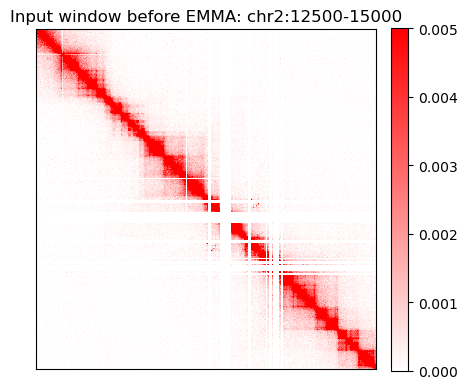

In [6]:
plot_arr = np.nan_to_num(mat_for_emma, nan=0.0, posinf=0.0, neginf=0.0)
pos = plot_arr[plot_arr > 0]
plot_vmax = np.nanpercentile(pos, 99.5) if len(pos) else None

plt.figure(figsize=(5, 5))
plt.matshow(mat[0:1000,0:1000], cmap=REDMAP,vmax = 0.005)
plt.title(f"Input window before EMMA: {chrom}:{window_start}-{window_end}")
plt.xticks([])
plt.yticks([])
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()


## Inspect and detect real missing bins

No artificial mask is created. The detector uses the real low-coverage or missing rows/columns in the selected matrix.


[max_diag] 500
[Exact empty/low-finite bins]
[441, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 521, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 621, 622, 623, 624, 625, 626, 627, 628, 629, 630, 675, 676, 679, 684, 686, 687, 688, 690, 691, 694, 695, 696, 697, 698, 699, 700, 701, 702, 704, 705, 706, 707, 708, 709, 710, 711, 712, 715, 718, 719, 720, 721, 722, 723, 724, 891, 1207, 1886]
[Exact empty/low-finite regions]
[(441, 442), (503, 513), (521, 522), (540, 572), (621, 631), (675, 677), (679, 680), (684, 685), (686, 689), (690, 692), (694, 703), (704, 713), (715, 716), (718, 725), (891, 892), (1207, 1208), (1886, 1887)]


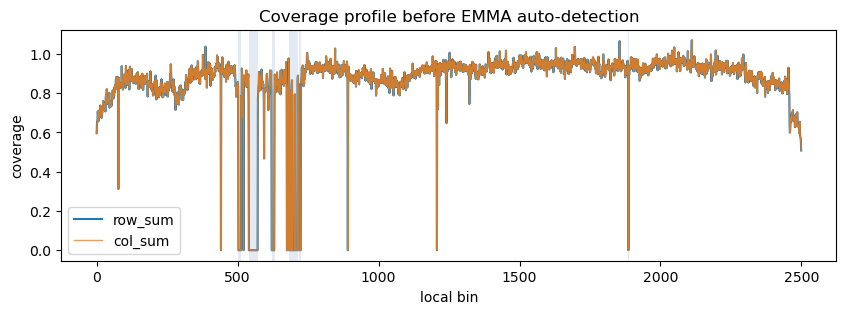

In [7]:
max_diag = min(500, mat_for_emma.shape[0] - 1)
auto_mask_mode = "aggressive"

finite = np.isfinite(mat_raw)
row_sum = np.nan_to_num(mat_raw, nan=0.0, posinf=0.0, neginf=0.0).sum(axis=1)
col_sum = np.nan_to_num(mat_raw, nan=0.0, posinf=0.0, neginf=0.0).sum(axis=0)
finite_ratio = finite.mean(axis=1)

exact_empty_bins = np.where(
    (row_sum <= 0) | (col_sum <= 0) | (finite_ratio < 0.5)
)[0].astype(int).tolist()
exact_empty_regions = merge_bins_to_regions(exact_empty_bins)

print("[max_diag]", max_diag)
print("[Exact empty/low-finite bins]")
print(exact_empty_bins)
print("[Exact empty/low-finite regions]")
print(exact_empty_regions)

plt.figure(figsize=(10, 3))
plt.plot(row_sum, label="row_sum", linewidth=1.5)
plt.plot(col_sum, label="col_sum", linewidth=1.0, alpha=0.8)
for s, e in exact_empty_regions:
    plt.axvspan(s, e, color="lightsteelblue", alpha=0.35, linewidth=0)
plt.title("Coverage profile before EMMA auto-detection")
plt.xlabel("local bin")
plt.ylabel("coverage")
plt.legend()
plt.show()


In [8]:
mask_info = detect_missing_bins(
    mat_raw,
    chrom=chrom,
    resolution=resolution,
    mode=auto_mask_mode,
    max_diag=max_diag,
)

if not mask_info.missing_bins:
    raise RuntimeError("No missing bins were detected. Try auto_mask_mode='aggressive' or inspect mat_raw manually.")

print("[EMMA auto-detect mode]", auto_mask_mode)
print("[Detected missing bins]")
print(mask_info.missing_bins)
print("[Detected missing regions, local bins]")
print(mask_info.regions)
print("[Detected missing regions, genomic bins]")
print([(window_start + s, window_start + e) for s, e in mask_info.regions])
print("[Detected missing regions, bp]")
print([((window_start + s) * resolution, (window_start + e) * resolution) for s, e in mask_info.regions])
print("[Mask points]", int(mask_info.mask.sum()))


[EMMA auto-detect mode] aggressive
[Detected missing bins]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 77, 181, 200, 201, 202, 203, 212, 218, 219, 220, 221, 222, 223, 224, 234, 235, 236, 244, 245, 252, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 302, 303, 304, 305, 306, 307, 308, 441, 495, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 521, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 593, 594, 608, 609, 610, 611, 621, 622, 623, 624, 625, 626, 627, 628, 629, 630, 631, 675, 676, 677, 678, 679, 684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708,

## EMMA restoration

These settings prioritize restoration quality over speed.

Key choices:

- `preset="default"`
- `init_max_iter=30` for stronger context initialization
- `recompute_pseudo_emd=True` for higher-quality pseudo-mask training
- `patch_len=64`, `stride=16` for dense overlapping patches in a 200x200 window
- moderate IMF weights to avoid over-sharpening artifacts
- conservative `replace_strength=0.65`
- mild diagonal calibration and streak suppression

If this is too slow, reduce `epochs`, `n_samples`, or set `recompute_pseudo_emd=False`.


In [9]:
out_dir = Path("/mnt/disk1/duanran/emhic_baseline/emhic_code/EMMA_for_git/EMMA_tutorial_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

training_params = dict(
    preset="default",
    device="cuda:0",
    max_diag=max_diag,
    max_imfs=5,
    imf_weights=(0.05, 1.10, 1.10, 1.25, 0.90),
    residual_weight=1.0,

    epochs=18,
    patch_len=64,
    stride=16,
    n_samples=30000,
    batch_size=128,
    base_channels=64,
    depth=3,
    dropout=0.03,

    init_max_iter=30,
    init_sigma=1.2,
    init_rowcol_weight=0.70,
    init_local_weight=0.30,
    init_neighbor_window=80,
    init_neighbor_tau=30.0,

    replace_strength=0.65,
    obs_imf_beta=0.0,
    recompute_pseudo_emd=True,

    do_diag_calibration=True,
    diag_calib_strength=0.15,
    do_streak_suppression=True,
    streak_strength=0.02,

    num_workers=8,
    prefetch_factor=4,
    inference_batch_size=256,
    verbose=False,
)

print("[EMMA quality-first parameters]")
print(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in training_params.items()}, indent=2))
print("[Runtime note] GPU starts at Stage 2. Stage 0/1 are CPU preprocessing and EMD decomposition.")

start_time = time.perf_counter()
restorer = EmmaRestorer(**training_params)

result = restorer.restore(
    mat_for_emma,
    mask=mask_info.mask,
    regions=mask_info.regions,
)
runtime_seconds = time.perf_counter() - start_time

result.save(out_dir)
mask_info.save(out_dir, chrom=chrom, resolution=resolution)

restored = result.restored_matrix
prediction_only = result.prediction_only
finite_pred = np.isfinite(prediction_only)

np.save(out_dir / f"original_window_{window_start}_{window_end}.npy", mat_for_emma.astype(np.float32))
np.save(out_dir / f"raw_window_{window_start}_{window_end}.npy", mat_raw.astype(np.float32))
np.save(out_dir / f"auto_detect_mask_{window_start}_{window_end}.npy", mask_info.mask.astype(bool))
np.save(out_dir / f"auto_detect_restored_{window_start}_{window_end}.npy", restored.astype(np.float32))

observed = ~mask_info.mask
observed_diff = float(np.nanmax(np.abs(restored[observed] - mat_for_emma[observed]))) if np.any(observed) else None

tutorial_report = {
    "emma_version": emma_3dgenome.__version__,
    "mcool_path": mcool_path,
    "chrom": chrom,
    "resolution": resolution,
    "norm_type": norm_type,
    "window_start": int(window_start),
    "window_end": int(window_end),
    "matrix_shape": list(mat_for_emma.shape),
    "auto_mask_mode": auto_mask_mode,
    "detected_missing_bins": [int(x) for x in mask_info.missing_bins],
    "detected_missing_regions_local": [list(map(int, r)) for r in mask_info.regions],
    "detected_missing_regions_genomic_bins": [[int(window_start + s), int(window_start + e)] for s, e in mask_info.regions],
    "detected_missing_regions_bp": [[int((window_start + s) * resolution), int((window_start + e) * resolution)] for s, e in mask_info.regions],
    "mask_points": int(mask_info.mask.sum()),
    "finite_prediction_points": int(finite_pred.sum()),
    "observed_unchanged_max_abs_diff": observed_diff,
    "runtime_seconds": float(runtime_seconds),
    "training_params": {k: (list(v) if isinstance(v, tuple) else v) for k, v in training_params.items()},
    "emma_result_report": result.report,
}

(out_dir / "tutorial_report.json").write_text(json.dumps(tutorial_report, indent=2, default=str), encoding="utf-8")

print("[Restored shape]", restored.shape)
print("[Finite prediction points]", int(finite_pred.sum()))
print("[Observed unchanged max abs diff]", observed_diff)
print("[Runtime seconds]", round(runtime_seconds, 2))
print("[Saved outputs]", out_dir)


[EMMA quality-first parameters]
{
  "preset": "default",
  "device": "cuda:0",
  "max_diag": 500,
  "max_imfs": 5,
  "imf_weights": [
    0.05,
    1.1,
    1.1,
    1.25,
    0.9
  ],
  "residual_weight": 1.0,
  "epochs": 18,
  "patch_len": 64,
  "stride": 16,
  "n_samples": 30000,
  "batch_size": 128,
  "base_channels": 64,
  "depth": 3,
  "dropout": 0.03,
  "init_max_iter": 30,
  "init_sigma": 1.2,
  "init_rowcol_weight": 0.7,
  "init_local_weight": 0.3,
  "init_neighbor_window": 80,
  "init_neighbor_tau": 30.0,
  "replace_strength": 0.65,
  "obs_imf_beta": 0.0,
  "recompute_pseudo_emd": true,
  "do_diag_calibration": true,
  "diag_calib_strength": 0.15,
  "do_streak_suppression": true,
  "streak_strength": 0.02,
  "num_workers": 8,
  "prefetch_factor": 4,
  "inference_batch_size": 256,
  "verbose": false
}
[Runtime note] GPU starts at Stage 2. Stage 0/1 are CPU preprocessing and EMD decomposition.


/mnt/disk1/duanran/anaconda3/envs/chromnet/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/disk1/duanran/anaconda3/envs/chromnet/lib/python3.9/site-packages/PyEMD/EMD.py:751: RuntimeWarning: divide by zero encountered in divide
  std = np.sum((imf_diff / imf_new) ** 2)


[Restored shape] (2500, 2500)
[Finite prediction points] 387064
[Observed unchanged max abs diff] 0.0
[Runtime seconds] 651.81
[Saved outputs] /mnt/disk1/duanran/emhic_baseline/emhic_code/EMMA_for_git/EMMA_tutorial_outputs


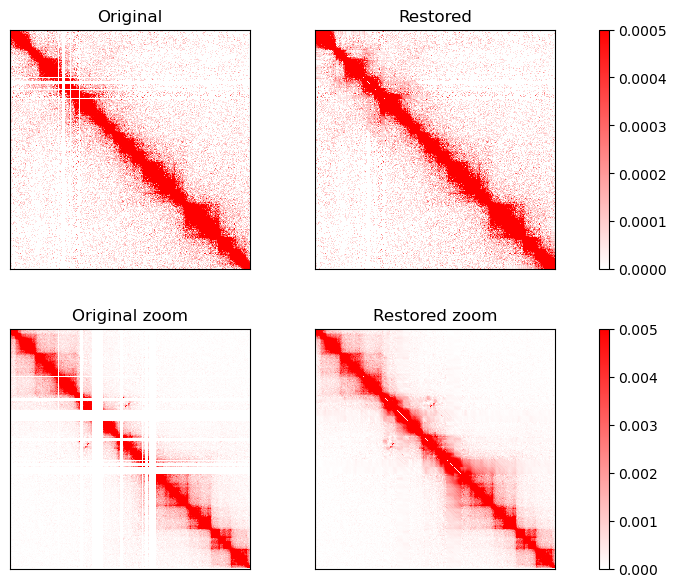

In [10]:
fig = plt.figure(figsize=(8, 7))

gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 0.035],
    height_ratios=[1, 1],
    wspace=0.12,
    hspace=0.25
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

cax0 = fig.add_subplot(gs[0, 2])
cax1 = fig.add_subplot(gs[1, 2])

titles = [
    "Original",
    "Restored",
    "Original zoom",
    "Restored zoom",
]

data_list = [
    mat,
    restored,
    mat[300:1000, 300:1000],
    restored[300:1000, 300:1000],
]

vmax_list = [
    0.0005,
    0.0005,
    0.005,
    0.005,
]

ims = []
for ax, data, title, vmax in zip(axes, data_list, titles, vmax_list):
    im = ax.imshow(
        data,
        cmap=REDMAP,
        vmin=0,
        vmax=vmax,
        interpolation="nearest"
    )
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ims.append(im)

fig.colorbar(ims[1], cax=cax0)
fig.colorbar(ims[3], cax=cax1)

plt.show()

## Output files

The tutorial writes outputs to:

```text
/mnt/disk1/user/EMMA_tutorial_outputs/
```

Key files:

- `emma_tutorial_quality_first_result.png`
- `tutorial_report.json`
- `auto_mask_diagnostics.tsv`
- `detected_missing_bins.tsv`
- `detected_missing_regions.bed`
- `original_window.npy`
- `raw_window.npy`
- `auto_detect_mask.npy`
- `auto_detect_restored.npy`
- EMMA standard outputs: `restored.npy`, `prediction_only.npy`, `mask.npy`, `report.json`, `diag_stats.json`, `log.txt`

Quality-first mode is intentionally slower than the fast tutorial mode. The key quality switch is `recompute_pseudo_emd=True`.
